Bài 1


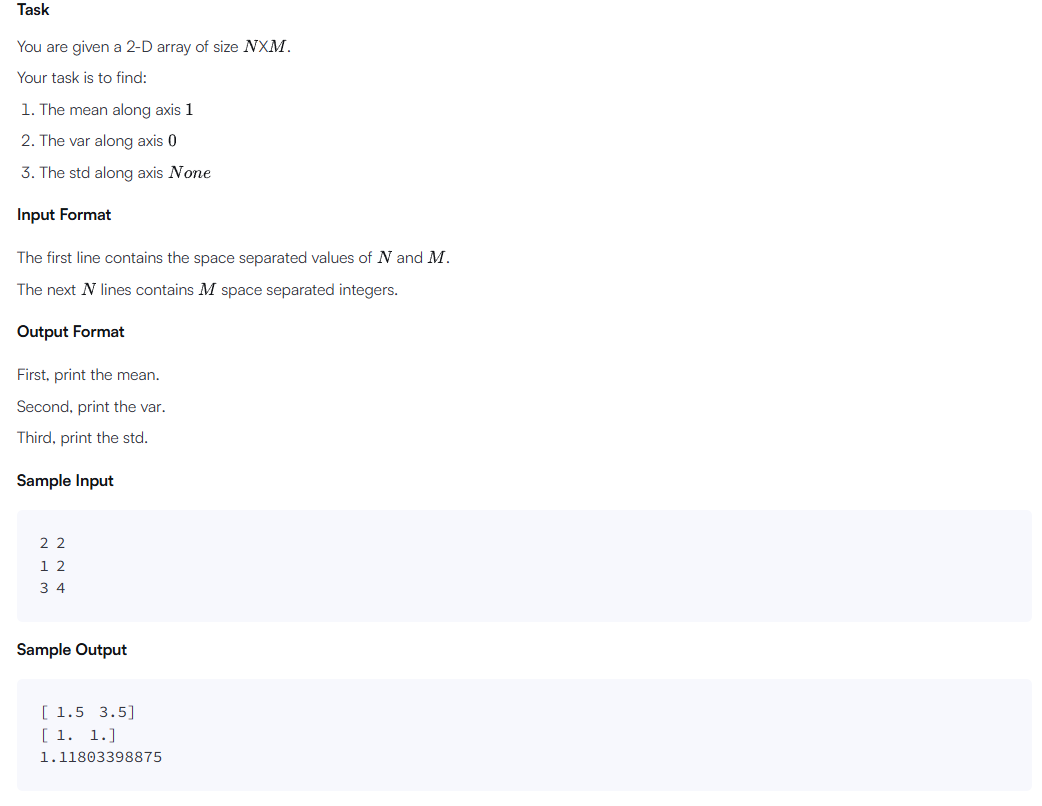

In [ ]:
import numpy as np

def solve_mean_var_std(input_text):
    lines = input_text.strip().splitlines() #Chặt input thành nhiều dòng
    n, m = map(int, lines[0].split()) #lấy dòng đầu tiên, map 2 số sang int lưu thành n, m
    a = np.array([list(map(int, line.split())) for line in lines[1:1 + n]]) #đọc mảng từ các dòng 1 tới dòng 1+n, mỗi dòng đọc thành một mảng lưu trong mảng to hơn (mảng chứa các dòng)
    return np.mean(a, axis=1), np.var(a, axis=0), round(float(np.std(a)), 11) #trả về các thông số đề bài yêu cầu theo tuple, làm tròn std tới 11 số thập phân


sample_input = """2 2
1 2
3 4
"""
mean_result, var_result, std_result = solve_mean_var_std(sample_input)
print(mean_result)
print(var_result)
print(std_result)


[1.5 3.5]
[1. 1.]
1.11803398875


Bài 2


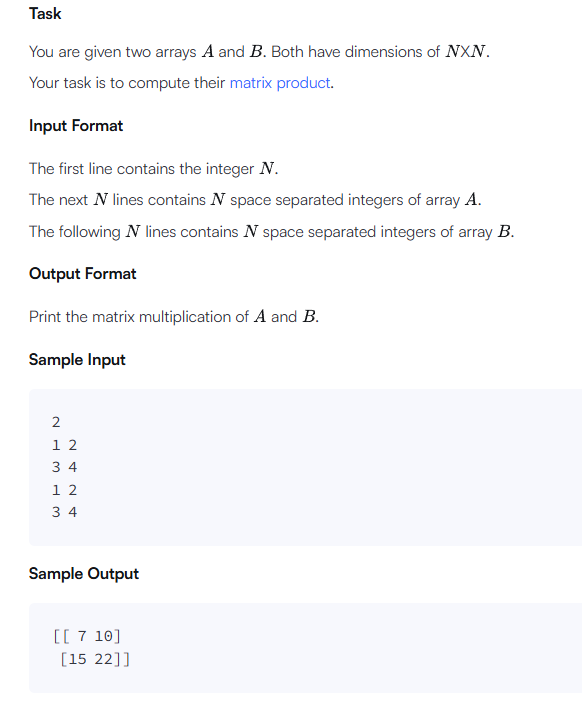

In [ ]:
import numpy as np
def solve_dot_and_cross(input_text):
    lines = input_text.strip().splitlines() #Cắt input theo từng dòng
    n = int(lines[0]) #Đọc n từ dòng đầu tiên
    A = np.array([list(map(int, line.split())) for line in lines[1:1 + n]]) #Đọc mảng A từ dòng 1 tới dòng n+1, mỗi hàng là 1 mảng được bọc trong mảng to hơn chứa các hàng
    B = np.array([list(map(int, line.split())) for line in lines[1 + n:1 + 2 * n]]) #Đọc mảng B từ dòng 1+n tới 1+2*n
    return A @ B #Trả về ma trận A @ B theo cú pháp của numpy.


sample_input = """2
1 2
3 4
1 2
3 4
"""
matrix_product = solve_dot_and_cross(sample_input)
print(matrix_product)

[[ 7 10]
 [15 22]]


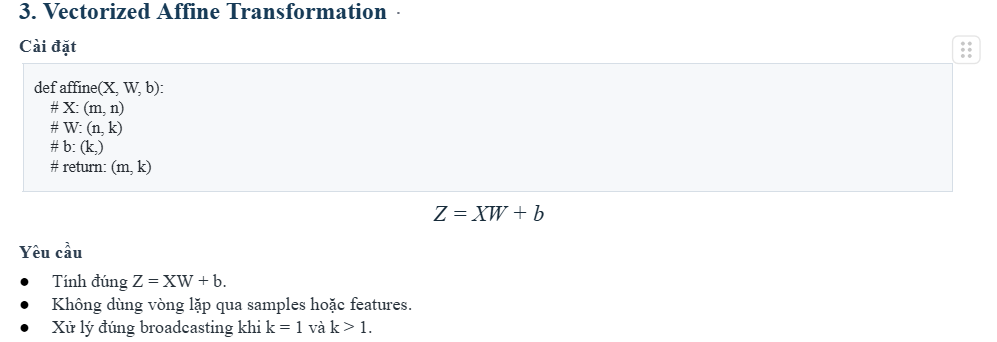

Ta có X shape là (m,n) W shape là (n,k). Khi đó X@W có shape là (m,k). b truyền vào có shape là (k,) được tự hiểu là (1,k) tức là 1 hàng k cột.
Với k=1: Ta cộng 1 số b duy nhất vào từng phần tử có trong 1 cột của X@W.
Với k>1: Numpy tự tách X@W ra thành k cột, sau đó mỗi cột được cộng các phần tử có trong mảng b từ trái qua phải.
Toàn bộ quá trình diễn ra tự động và như ý, không có vấn đề gì cả.
Broadcasting được numpy hiểu tự động thông qua toán tử + rồi
Tóm lại bài này cần đảm bảo đầu vào b là (1,k) hoặc (k,) chứ không phải (k,1), em nghĩ thế



In [ ]:
def affine(X,W,b): #Bài này k có bằng bao nhiêu đi nữa thì nó vẫn tự xử lí đúng broadcast mà...
  return X@W+b

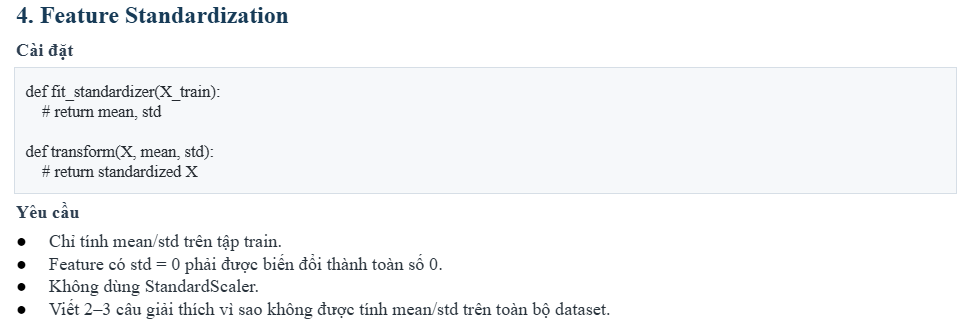

In [ ]:
import numpy as np

def fit_standardizer(X_train):
  #input: X_train (m,n)
  #output: mean (1,n), std (1,n)

    X_train = np.asarray(X_train, dtype=float) #Đảm bảo mảng dữ liệu train truyền vào là mảng số thực, dùng asarray vì array tốn bộ nhớ tạo ra mảng copy thay vì inplace trong trường hợp mảng là mảng numpy sẵn
    mean = np.mean(X_train, axis=0) #Tìm ra mảng (1,n) chứa mean theo từng cột feature (với từng feature, tính mean cho toàn bộ dữ liệu)
    std = np.std(X_train, axis=0) #Tìm ra mảng (1,n) chứa độ lệch chuẩn theo từng cột feature
    return mean, std


def transform(X, mean, std):
  #X (m,n); mean (1,n); std (1,n)
    X = np.asarray(X, dtype=float)
    mean = np.asarray(mean, dtype=float)
    std = np.asarray(std, dtype=float)

    safe_std = np.where(std == 0, 1.0, std) #Phép thay thế, thay thế tất cả các vị trí trong mảng std có giá trị bằng 0 thành 1.
    standardized = (X - mean) / safe_std #Boardcast ở đây, từng dữ liệu trong cột của X sẽ bị trừ đi mean tương ứng của cột đó sau đó chia cho đlt tương ứng.

    return standardized

In [ ]:
##Code test case viết bằng AI
import numpy as np

# Giả sử bạn đã có sẵn 2 hàm fit_standardizer và transform của bạn ở đây

# --- Test Case 1: Dữ liệu đơn giản, số nguyên dương ---
X_test_1 = [[1, 2],
            [3, 4]]

# Tính thủ công:
# Mean: [(1+3)/2, (2+4)/2] = [2, 3]
# Std:
#   Cột 0: [1, 3] -> (1-2)^2 + (3-2)^2 = 2. Chia cho N=2 là 1. Căn bậc 2 là 1.
#   Cột 1: [2, 4] -> (2-3)^2 + (4-3)^2 = 2. Chia cho N=2 là 1. Căn bậc 2 là 1.

mean1, std1 = fit_standardizer(X_test_1)
res1 = transform(X_test_1, mean1, std1)

print("Kết quả test 1:")
print("Mean:", mean1) # Dự đoán: [2. 3.]
print("Std:", std1)   # Dự đoán: [1. 1.]
print("Transform:", res1)
# Dự đoán: [[-1. -1.]
#           [ 1.  1.]]


# --- Test Case 2: Dữ liệu có cột không đổi (trường hợp test safe_std) ---
X_test_2 = [[10, 5],
            [10, 5]]

# Tính thủ công:
# Mean: [10, 5]
# Std: Cột 0 là [10, 10] -> std=0. Cột 1 là [5, 5] -> std=0.
# Hàm của bạn sẽ thay std=0 bằng 1.0 (nhờ safe_std)

mean2, std2 = fit_standardizer(X_test_2)
res2 = transform(X_test_2, mean2, std2)

print("\nKết quả test 2 (Check safe_std):")
print("Mean:", mean2) # Dự đoán: [10. 5.]
print("Std:", std2)   # Dự đoán: [0. 0.]
print("Transform:", res2)
# Dự đoán: [[0. 0.]
#           [0. 0.]]
# Giải thích: X - mean = [0, 0]. Vì std=0 nên bị thay thế thành 1, 0/1 = 0.

Kết quả test 1:
Mean: [2. 3.]
Std: [1. 1.]
Transform: [[-1. -1.]
 [ 1.  1.]]

Kết quả test 2 (Check safe_std):
Mean: [10.  5.]
Std: [0. 0.]
Transform: [[0. 0.]
 [0. 0.]]


Chỉ tính mean và std trên tập dữ liệu train là bởi vì thường thì ta sẽ chia dataset làm 2 tập train và test. Nếu mean và std tính trên cả tập test thì ta đang gian lận biết trước tương lai, dẫn đến việc benchmark đánh giá model sau này không còn chính xác hoàn toàn.

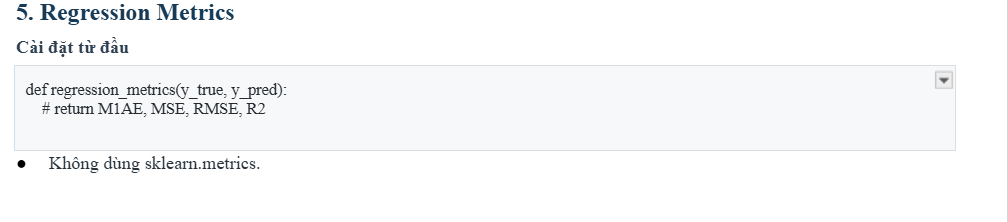

In [ ]:
import numpy as np

def regression_metrics(y_true, y_pred):
    # y_true, y_pred có thể là list, array 1D (N,) hoặc 2D (1, N)
    y_true = np.asarray(y_true, dtype=float).flatten()
    y_pred = np.asarray(y_pred, dtype=float).flatten()
    
    error = y_true - y_pred
    mae = np.mean(np.abs(error)) # Trung bình sai số tuyệt đối
    mse = np.mean(error ** 2) # Trung bình sai số bình phương
    rmse = np.sqrt(mse) # Căn bậc 2 của trung bình sai số bình phương
    
    ss_res = np.sum(error ** 2) # Tổng sai số bình phương dự đoán
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2) # Tổng sai số bình phương so với trung bình
    if ss_tot == 0: # Xử lý trường hợp mẫu hằng số
        r2 = 1.0 if ss_res == 0 else 0.0
    else:
        r2 = 1.0 - ss_res / ss_tot
        
    return float(mae), float(mse), float(rmse), float(r2)


Giải thích:

MAE = MEAN ABSOLUTE ERROR => Sử dụng khi ta không quan tâm tới việc dự đoán các giá trị ngoại lai.

MSE = MEAN SQUARE ERROR => Vô cùng nhạy cảm với ngoại lai do bị bình phương.

RMSE ROOT MEAN SQUARE ERROR => Vẫn nhạy cảm với ngoại lai, nhưng không làm mất đơn vị của kết quả đầu ra. (Recommended).

R2 = càng gần 1 thì càng khớp dữ liệu thực tế. Bằng 0 nghĩa là mô hình chán như ko dự đoán, chỉ spam giá trị trung bình. Bé hơn 0 nghĩa là mô hình còn tệ hơn cả một mô hình spam giá trị trung bình.

In [ ]:
# ==============================================================================
# IMPLEMENTATION & TEST SUITE FOR REGRESSION METRICS
# ==============================================================================

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def regression_metrics(y_true, y_pred):
    """
    Tính toán các chỉ số đánh giá mô hình Regression: MAE, MSE, RMSE, R2.
    
    Parameters:
    y_true: array-like, shape (N,) hoặc (1, N) - Giá trị thực tế.
    y_pred: array-like, shape (N,) hoặc (1, N) - Giá trị dự đoán từ mô hình.
    
    Returns:
    tuple: (mae, mse, rmse, r2)
    """
    # Chuyển đổi đầu vào thành numpy array kiểu float để đảm bảo tính toán chính xác
    y_true = np.asarray(y_true, dtype=float).flatten()
    y_pred = np.asarray(y_pred, dtype=float).flatten()
    
    # Sai số dự đoán
    error = y_true - y_pred
    
    # 1. MAE (Mean Absolute Error) - Sai số tuyệt đối trung bình
    mae = np.mean(np.abs(error))
    
    # 2. MSE (Mean Squared Error) - Sai số bình phương trung bình
    mse = np.mean(error ** 2)
    
    # 3. RMSE (Root Mean Squared Error) - Căn bậc hai sai số bình phương trung bình
    rmse = np.sqrt(mse)
    
    # 4. R2 Score (Coefficient of Determination) - Hệ số xác định
    ss_res = np.sum(error ** 2)  # Tổng bình phương sai số dự đoán
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)  # Tổng bình phương sai số so với trung bình
    
    # Xử lý trường hợp ss_tot == 0 (y_true là hằng số)
    if ss_tot == 0:
        r2 = 1.0 if ss_res == 0 else 0.0
    else:
        r2 = 1.0 - (ss_res / ss_tot)
        
    return float(mae), float(mse), float(rmse), float(r2)


# ==============================================================================
# BỘ TEST CASES KIỂM THỬ TÍNH ĐÚNG ĐẮN CỦA HÀM REGRESSION_METRICS
# ==============================================================================

print("=" * 75)
print("    BẮT ĐẦU CHẠY KIỂM THỬ HÀM REGRESSION_METRICS")
print("=" * 75)

# --- Test Case 1: Dự đoán hoàn hảo (Perfect Prediction) ---
y_t1 = [1.0, 2.0, 3.0, 4.0, 5.0]
y_p1 = [1.0, 2.0, 3.0, 4.0, 5.0]
mae1, mse1, rmse1, r21 = regression_metrics(y_t1, y_p1)

print()
print("[Test 1] Dự đoán hoàn hảo (Perfect Prediction):")
print(f"  -> MAE  = {mae1:.4f} (Kỳ vọng: 0.0000)")
print(f"  -> MSE  = {mse1:.4f} (Kỳ vọng: 0.0000)")
print(f"  -> RMSE = {rmse1:.4f} (Kỳ vọng: 0.0000)")
print(f"  -> R2   = {r21:.4f} (Kỳ vọng: 1.0000)")
assert mae1 == 0.0 and mse1 == 0.0 and rmse1 == 0.0 and r21 == 1.0, "Test 1 thất bại!"
print("  => STATUS: PASSED ✓")


# --- Test Case 2: Dữ liệu tính toán thủ công (Manual Verification) ---
y_t2 = [10.0, 20.0, 30.0, 40.0]
y_p2 = [12.0, 18.0, 33.0, 37.0]
mae2, mse2, rmse2, r22 = regression_metrics(y_t2, y_p2)

print()
print("[Test 2] Tính toán theo dữ liệu kiểm thử chuẩn:")
print(f"  -> MAE  = {mae2:.4f} (Kỳ vọng: 2.5000)")
print(f"  -> MSE  = {mse2:.4f} (Kỳ vọng: 6.5000)")
print(f"  -> RMSE = {rmse2:.4f} (Kỳ vọng: 2.5495)")
print(f"  -> R2   = {r22:.4f} (Kỳ vọng: 0.9480)")
assert np.isclose(mae2, 2.5) and np.isclose(mse2, 6.5) and np.isclose(r22, 0.948), "Test 2 thất bại!"
print("  => STATUS: PASSED ✓")


# --- Test Case 3: Dự đoán bằng giá trị trung bình (Baseline Mean Predictor) ---
y_t3 = [1.0, 3.0, 5.0, 7.0]
y_p3 = [4.0, 4.0, 4.0, 4.0]
mae3, mse3, rmse3, r23 = regression_metrics(y_t3, y_p3)

print()
print("[Test 3] Mô hình Baseline (Luôn dự đoán mean):")
print(f"  -> MAE  = {mae3:.4f}")
print(f"  -> MSE  = {mse3:.4f}")
print(f"  -> RMSE = {rmse3:.4f}")
print(f"  -> R2   = {r23:.4f} (Kỳ vọng: 0.0000)")
assert np.isclose(r23, 0.0), "Test 3 thất bại!"
print("  => STATUS: PASSED ✓")


# --- Test Case 4: Mô hình dự đoán rất kém (R2 âm) ---
y_t4 = [1.0, 2.0, 3.0]
y_p4 = [10.0, -5.0, 15.0]
mae4, mse4, rmse4, r24 = regression_metrics(y_t4, y_p4)

print()
print("[Test 4] Mô hình kém hơn Baseline (R2 âm):")
print(f"  -> R2   = {r24:.4f} (Kỳ vọng: < 0.0)")
assert r24 < 0.0, "Test 4 thất bại!"
print("  => STATUS: PASSED ✓")


# --- Test Case 5: Đa dạng Kích thước Shape (Matrix 2D: (1, N) & (N, 1)) ---
y_t5 = np.array([[1.0, 2.0, 3.0, 4.0]])
y_p5 = np.array([[1.5, 2.5, 2.5, 3.5]])
mae5, mse5, rmse5, r25 = regression_metrics(y_t5, y_p5)

print()
print("[Test 5] Đa dạng shape dữ liệu đầu vào (2D Arrays):")
print(f"  -> MAE  = {mae5:.4f}, MSE = {mse5:.4f}, RMSE = {rmse5:.4f}, R2 = {r25:.4f}")
assert np.isclose(mae5, 0.5), "Test 5 thất bại!"
print("  => STATUS: PASSED ✓")


# --- Test Case 6: Đối chiếu trực tiếp với thư viện scikit-learn ---
np.random.seed(42)
y_t6 = np.random.randn(100) * 10 + 50
y_p6 = y_t6 + np.random.randn(100) * 2

mae6, mse6, rmse6, r26 = regression_metrics(y_t6, y_p6)

sk_mae = mean_absolute_error(y_t6, y_p6)
sk_mse = mean_squared_error(y_t6, y_p6)
sk_rmse = np.sqrt(sk_mse)
sk_r2 = r2_score(y_t6, y_p6)

print()
print("[Test 6] Cross-check tự động với scikit-learn (100 mẫu ngẫu nhiên):")
print(f"  -> Custom MAE : {mae6:.6f} | Sklearn MAE : {sk_mae:.6f}")
print(f"  -> Custom MSE : {mse6:.6f} | Sklearn MSE : {sk_mse:.6f}")
print(f"  -> Custom RMSE: {rmse6:.6f} | Sklearn RMSE: {sk_rmse:.6f}")
print(f"  -> Custom R2  : {r26:.6f} | Sklearn R2  : {sk_r2:.6f}")

assert np.isclose(mae6, sk_mae), "MAE không khớp với sklearn!"
assert np.isclose(mse6, sk_mse), "MSE không khớp với sklearn!"
assert np.isclose(rmse6, sk_rmse), "RMSE không khớp với sklearn!"
assert np.isclose(r26, sk_r2), "R2 không khớp với sklearn!"
print("  => STATUS: PASSED ✓ (Khớp 100% với scikit-learn)")

print()
print("=" * 75)
print("    TẤT CẢ CÁC TEST CASES ĐÃ ĐẠT KẾT QUẢ TỐT (ALL TESTS PASSED)")
print("=" * 75)
